<a href="https://colab.research.google.com/github/ZinahO/Composer-Classification-Using-Deep-Learning-_-AAI511_G5/blob/main/Final_Project_AAI511_G5_Part_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 14. LSTM Model Development
Using the preprocessed sequence data prepared earlier in the project section, we created an LSTM model for composer classification.

The goal of this LSTM model development is to load the processed sequence arrays, examine the input dimensions, address class imbalance, then build a baseline LSTM model, train and tune the model, and evaluate performance using accuracy, precision, F1-score, and recall.

## 14.0 Prepare Processed Data for LSTM Modeling


In [1]:
!unzip -o /content/composer_classification_processed.zip -d /content/

Archive:  /content/composer_classification_processed.zip
  inflating: /content/composer_classification_processed/X_dev.npy  
  inflating: /content/composer_classification_processed/processing_configuration.json  
  inflating: /content/composer_classification_processed/y_dev.npy  
  inflating: /content/composer_classification_processed/sequence_metadata.csv  
  inflating: /content/composer_classification_processed/composer_labels.json  
  inflating: /content/composer_classification_processed/dataset_split_inventory.csv  
  inflating: /content/composer_classification_processed/y_train.npy  
  inflating: /content/composer_classification_processed/y_test.npy  
  inflating: /content/composer_classification_processed/X_test.npy  
  inflating: /content/composer_classification_processed/X_train.npy  


In [2]:
from pathlib import Path
import os

PROCESSED_DIR = Path("/content/composer_classification_processed")

required_files = [
    "X_train.npy",
    "y_train.npy",
    "X_dev.npy",
    "y_dev.npy",
    "X_test.npy",
    "y_test.npy",
    "composer_labels.json",
    "processing_configuration.json"
]

print("Processed directory exists:", PROCESSED_DIR.exists())
print()

missing_files = []
for file_name in required_files:
    file_path = PROCESSED_DIR / file_name
    exists = file_path.exists()
    print(f"{file_name}: {'FOUND' if exists else 'MISSING'}")
    if not exists:
        missing_files.append(file_name)

if missing_files:
    print("\nMissing files:", missing_files)
else:
    print("\nAll required processed files are present.")

Processed directory exists: True

X_train.npy: FOUND
y_train.npy: FOUND
X_dev.npy: FOUND
y_dev.npy: FOUND
X_test.npy: FOUND
y_test.npy: FOUND
composer_labels.json: FOUND
processing_configuration.json: FOUND

All required processed files are present.


In [3]:
import numpy as np
import json

X_train = np.load(PROCESSED_DIR / "X_train.npy").astype(np.float32)
y_train = np.load(PROCESSED_DIR / "y_train.npy").reshape(-1).astype(np.int32)

X_dev = np.load(PROCESSED_DIR / "X_dev.npy").astype(np.float32)
y_dev = np.load(PROCESSED_DIR / "y_dev.npy").reshape(-1).astype(np.int32)

X_test = np.load(PROCESSED_DIR / "X_test.npy").astype(np.float32)
y_test = np.load(PROCESSED_DIR / "y_test.npy").reshape(-1).astype(np.int32)

with open(PROCESSED_DIR / "composer_labels.json", "r") as f:
    composer_labels = json.load(f)

with open(PROCESSED_DIR / "processing_configuration.json", "r") as f:
    processing_config = json.load(f)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_dev shape:", X_dev.shape)
print("y_dev shape:", y_dev.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Composer labels:", composer_labels)

X_train shape: (3417, 2000, 7)
y_train shape: (3417,)
X_dev shape: (244, 2000, 7)
y_dev shape: (244,)
X_test shape: (245, 2000, 7)
y_test shape: (245,)
Composer labels: {'bach': 0, 'beethoven': 1, 'chopin': 2, 'mozart': 3}


In [4]:
print("Training dtype:", X_train.dtype, y_train.dtype)
print("Validation dtype:", X_dev.dtype, y_dev.dtype)
print("Test dtype:", X_test.dtype, y_test.dtype)

print("Any NaNs in X_train:", np.isnan(X_train).any())
print("Any NaNs in X_dev:", np.isnan(X_dev).any())
print("Any NaNs in X_test:", np.isnan(X_test).any())

print("Unique training labels:", np.unique(y_train))
print("Unique validation labels:", np.unique(y_dev))
print("Unique test labels:", np.unique(y_test))

Training dtype: float32 int32
Validation dtype: float32 int32
Test dtype: float32 int32
Any NaNs in X_train: False
Any NaNs in X_dev: False
Any NaNs in X_test: False
Unique training labels: [0 1 2 3]
Unique validation labels: [0 1 2 3]
Unique test labels: [0 1 2 3]


## 14.1 Import Model Training Libraries


In [5]:
import random
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sklearn

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Masking, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

## 14.2 Define the Processed Data Folder


In [6]:
PROCESSED_DIR = Path("/content/composer_classification_processed")
print("Processed data folder:", PROCESSED_DIR)

Processed data folder: /content/composer_classification_processed


## 14.3 Check for Required Processed Files

In [7]:
required_files = [
    "X_train.npy",
    "y_train.npy",
    "X_dev.npy",
    "y_dev.npy",
    "X_test.npy",
    "y_test.npy",
    "composer_labels.json",
    "processing_configuration.json"
]

print("Processed directory exists:", PROCESSED_DIR.exists())
print()

missing_files = []
for file_name in required_files:
    file_path = PROCESSED_DIR / file_name
    exists = file_path.exists()
    print(f"{file_name}: {'FOUND' if exists else 'MISSING'}")
    if not exists:
        missing_files.append(file_name)

if missing_files:
    print("\nMissing files:", missing_files)
else:
    print("\nAll required processed files are present.")

Processed directory exists: True

X_train.npy: FOUND
y_train.npy: FOUND
X_dev.npy: FOUND
y_dev.npy: FOUND
X_test.npy: FOUND
y_test.npy: FOUND
composer_labels.json: FOUND
processing_configuration.json: FOUND

All required processed files are present.


## 14.4 Load the Processed Sequence Arrays


In [8]:
X_train = np.load(PROCESSED_DIR / "X_train.npy").astype(np.float32)
y_train = np.load(PROCESSED_DIR / "y_train.npy").reshape(-1).astype(np.int32)

X_dev = np.load(PROCESSED_DIR / "X_dev.npy").astype(np.float32)
y_dev = np.load(PROCESSED_DIR / "y_dev.npy").reshape(-1).astype(np.int32)

X_test = np.load(PROCESSED_DIR / "X_test.npy").astype(np.float32)
y_test = np.load(PROCESSED_DIR / "y_test.npy").reshape(-1).astype(np.int32)

with open(PROCESSED_DIR / "composer_labels.json", "r") as f:
    composer_labels = json.load(f)

with open(PROCESSED_DIR / "processing_configuration.json", "r") as f:
    processing_config = json.load(f)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_dev shape:", X_dev.shape)
print("y_dev shape:", y_dev.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Composer labels:", composer_labels)

X_train shape: (3417, 2000, 7)
y_train shape: (3417,)
X_dev shape: (244, 2000, 7)
y_dev shape: (244,)
X_test shape: (245, 2000, 7)
y_test shape: (245,)
Composer labels: {'bach': 0, 'beethoven': 1, 'chopin': 2, 'mozart': 3}


## 14.5 Perform Data Sanity Checks

In [9]:
print("Training dtype:", X_train.dtype, y_train.dtype)
print("Validation dtype:", X_dev.dtype, y_dev.dtype)
print("Test dtype:", X_test.dtype, y_test.dtype)

print("Any NaNs in X_train:", np.isnan(X_train).any())
print("Any NaNs in X_dev:", np.isnan(X_dev).any())
print("Any NaNs in X_test:", np.isnan(X_test).any())

print("Unique training labels:", np.unique(y_train))
print("Unique validation labels:", np.unique(y_dev))
print("Unique test labels:", np.unique(y_test))

Training dtype: float32 int32
Validation dtype: float32 int32
Test dtype: float32 int32
Any NaNs in X_train: False
Any NaNs in X_dev: False
Any NaNs in X_test: False
Unique training labels: [0 1 2 3]
Unique validation labels: [0 1 2 3]
Unique test labels: [0 1 2 3]


## 14.6 Inspect Class Distribution and Compute Class Weights

In [10]:
class_counts = pd.Series(y_train).value_counts().sort_index()
print("Training class counts:")
print(class_counts)

class_names = [k for k, v in sorted(composer_labels.items(), key=lambda x: x[1])]
print("\nClass index to composer mapping:")
for idx, name in enumerate(class_names):
    print(f"{idx}: {name}")

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {int(cls): float(w) for cls, w in zip(classes, weights)}

print("\nComputed class weights:")
for cls, weight in class_weight_dict.items():
    print(f"Class {cls} ({class_names[cls]}): {weight:.4f}")

Training class counts:
0    2151
1     444
2     285
3     537
Name: count, dtype: int64

Class index to composer mapping:
0: bach
1: beethoven
2: chopin
3: mozart

Computed class weights:
Class 0 (bach): 0.3971
Class 1 (beethoven): 1.9240
Class 2 (chopin): 2.9974
Class 3 (mozart): 1.5908


## 14.7 Set Random Seeds for Reproducibility


In [11]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seeds set to:", SEED)

Random seeds set to: 42


## 14.8 Build the Baseline LSTM Model

In [12]:
num_timesteps = X_train.shape[1]
num_features = X_train.shape[2]
num_classes = len(np.unique(y_train))

print("Timesteps:", num_timesteps)
print("Features:", num_features)
print("Classes:", num_classes)

baseline_lstm = Sequential([
    Input(shape=(num_timesteps, num_features)),
    Masking(mask_value=0.0),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

baseline_lstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_lstm.summary()

Timesteps: 2000
Features: 7
Classes: 4


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 2000, 7)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,852 (89.27 KB)

 Trainable params: 22,852 (89.27 KB)

 Non-trainable params: 0 (0.00 B)

# 15. LSTM Training and Hyperparameter Tuning

In this section, we train the baseline LSTM model. We then test a tuned LSTM configuration to improve performance.

## 15.1 Define Baseline Training Callbacks

In [13]:
baseline_checkpoint_path = PROCESSED_DIR / "baseline_lstm_best.keras"

baseline_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=str(baseline_checkpoint_path),
        monitor="val_loss",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

print("Baseline checkpoint path:", baseline_checkpoint_path)

Baseline checkpoint path: /content/composer_classification_processed/baseline_lstm_best.keras


## 15.2 Train the Baseline LSTM Model

In [14]:
baseline_history = baseline_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_dev, y_dev),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=baseline_callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.5048 - loss: 1.3423 - val_accuracy: 0.5779 - val_loss: 1.2387 - learning_rate: 0.0010
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 269s 3s/step - accuracy: 0.5830 - loss: 1.2595 - val_accuracy: 0.5574 - val_loss: 1.1761 - learning_rate: 0.0010
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 320s 3s/step - accuracy: 0.5938 - loss: 1.2151 - val_accuracy: 0.5697 - val_loss: 1.1813 - learning_rate: 0.0010
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 273s 3s/step - accuracy: 0.5982 - loss: 1.2038 - val_accuracy: 0.5656 - val_loss: 1.1727 - learning_rate: 0.0010
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.6207 - loss: 1.1729 - val_accuracy: 0.5984 - val_loss: 1.1138 - learning_rate: 0.0010
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.6172 - loss: 1.1435 - val_accuracy: 0.6230 - val_loss: 1.0328 - learning_rate: 0.0010
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.6336 - loss: 1.

## 15.3 Plot and Save Baseline Training History

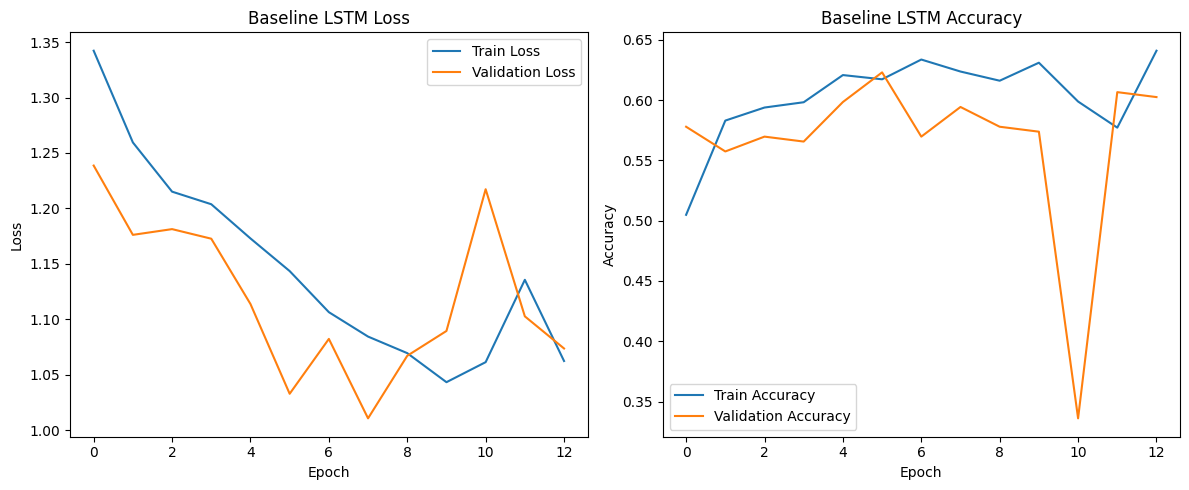

Saved baseline history plot to: /content/composer_classification_processed/baseline_lstm_history.png


In [15]:
baseline_history_df = pd.DataFrame(baseline_history.history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_history_df["loss"], label="Train Loss")
plt.plot(baseline_history_df["val_loss"], label="Validation Loss")
plt.title("Baseline LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(baseline_history_df["accuracy"], label="Train Accuracy")
plt.plot(baseline_history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()

baseline_history_plot_path = PROCESSED_DIR / "baseline_lstm_history.png"
plt.savefig(baseline_history_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved baseline history plot to:", baseline_history_plot_path)

## 15.4 Build the Tuned LSTM Model

In [16]:
tuned_lstm = Sequential([
    Input(shape=(num_timesteps, num_features)),
    Masking(mask_value=0.0),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

tuned_lstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tuned_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 2000, 7)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 2000, 128)      │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,460 (482.27 KB)

 Trainable params: 123,460 (482.27 KB)

 Non-trainable params: 0 (0.00 B)

## 15.5 Define Training Callbacks for the Tuned Model

In [17]:
tuned_checkpoint_path = PROCESSED_DIR / "tuned_lstm_best.keras"

tuned_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=str(tuned_checkpoint_path),
        monitor="val_loss",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

print("Tuned checkpoint path:", tuned_checkpoint_path)

Tuned checkpoint path: /content/composer_classification_processed/tuned_lstm_best.keras


## 15.6 Train the Tuned LSTM Model

In [28]:
tuned_history = tuned_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_dev, y_dev),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=tuned_callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 573s 5s/step - accuracy: 0.6877 - loss: 0.8811 - val_accuracy: 0.6352 - val_loss: 1.0455 - learning_rate: 2.5000e-04
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 565s 5s/step - accuracy: 0.6833 - loss: 0.8700 - val_accuracy: 0.6230 - val_loss: 1.0521 - learning_rate: 2.5000e-04
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 623s 5s/step - accuracy: 0.6661 - loss: 0.9086 - val_accuracy: 0.6189 - val_loss: 1.0856 - learning_rate: 2.5000e-04
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 567s 5s/step - accuracy: 0.6831 - loss: 0.8581 - val_accuracy: 0.6107 - val_loss: 1.0670 - learning_rate: 1.2500e-04
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 567s 5s/step - accuracy: 0.6986 - loss: 0.8446 - val_accuracy: 0.6352 - val_loss: 1.0626 - learning_rate: 1.2500e-04


## 15.7 Plot and Save Tuned Training History

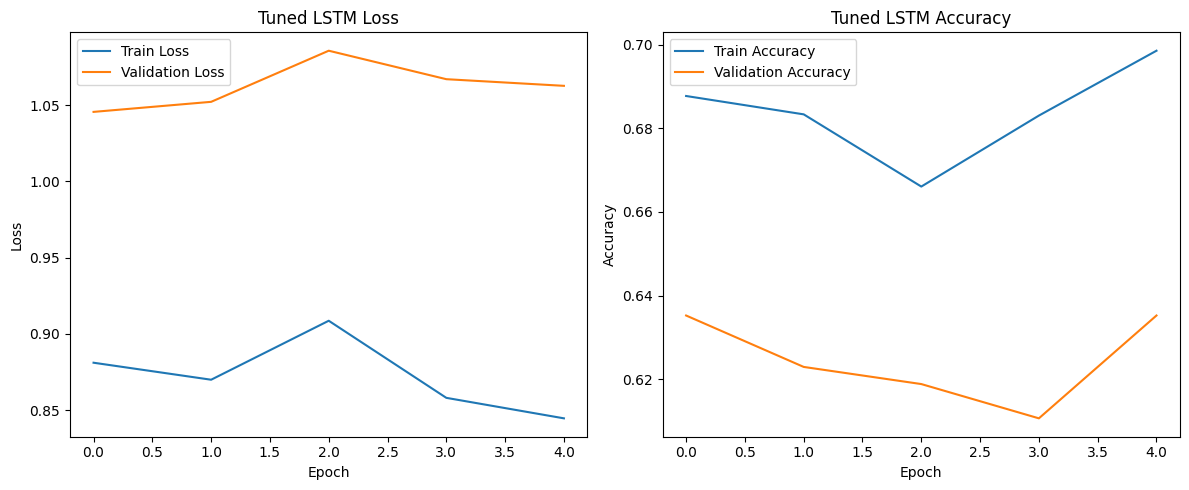

Saved tuned history plot to: /content/composer_classification_processed/tuned_lstm_history.png


In [29]:
tuned_history_df = pd.DataFrame(tuned_history.history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tuned_history_df["loss"], label="Train Loss")
plt.plot(tuned_history_df["val_loss"], label="Validation Loss")
plt.title("Tuned LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(tuned_history_df["accuracy"], label="Train Accuracy")
plt.plot(tuned_history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Tuned LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()

tuned_history_plot_path = PROCESSED_DIR / "tuned_lstm_history.png"
plt.savefig(tuned_history_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved tuned history plot to:", tuned_history_plot_path)

## 15.8 Save Hyperparameter Summary

In [30]:
hyperparameter_summary = pd.DataFrame([
    {
        "model": "baseline_lstm",
        "lstm_units_1": 64,
        "lstm_units_2": None,
        "dropout": 0.3,
        "dense_units": 64,
        "batch_size": 32,
        "epochs": 20,
        "optimizer": "adam"
    },
    {
        "model": "tuned_lstm",
        "lstm_units_1": 128,
        "lstm_units_2": 64,
        "dropout": 0.3,
        "dense_units": 64,
        "batch_size": 32,
        "epochs": 20,
        "optimizer": "adam"
    }
])

hyperparameter_summary_path = PROCESSED_DIR / "lstm_hyperparameter_summary.csv"
hyperparameter_summary.to_csv(hyperparameter_summary_path, index=False)

print("Saved hyperparameter summary to:", hyperparameter_summary_path)
print(hyperparameter_summary)

Saved hyperparameter summary to: /content/composer_classification_processed/lstm_hyperparameter_summary.csv
           model  lstm_units_1  lstm_units_2  dropout  dense_units  \
0  baseline_lstm            64           NaN      0.3           64   
1     tuned_lstm           128          64.0      0.3           64   

   batch_size  epochs optimizer  
0          32      20      adam  
1          32      20      adam  


# 16. LSTM Evaluation Results

In this section, we evaluate the baseline and tuned LSTM models on the held-out test set using accuracy, precision, F-1 score, and recall. For error analysis, a classification report and confusion matrix are included.


## 16.1 Evaluate the Baseline LSTM Model


In [31]:
baseline_probs = baseline_lstm.predict(X_test)
baseline_preds = np.argmax(baseline_probs, axis=1)

baseline_test_loss, baseline_test_acc_keras = baseline_lstm.evaluate(X_test, y_test, verbose=0)
baseline_accuracy = accuracy_score(y_test, baseline_preds)
baseline_precision = precision_score(y_test, baseline_preds, average="weighted", zero_division=0)
baseline_recall = recall_score(y_test, baseline_preds, average="weighted", zero_division=0)
baseline_f1 = f1_score(y_test, baseline_preds, average="weighted", zero_division=0)

print("Baseline Test Loss:", round(baseline_test_loss, 4))
print("Baseline Test Accuracy:", round(baseline_accuracy, 4))
print("Baseline Test Precision:", round(baseline_precision, 4))
print("Baseline Test Recall:", round(baseline_recall, 4))
print("Baseline Test F1-score:", round(baseline_f1, 4))

baseline_report_dict = classification_report(
    y_test,
    baseline_preds,
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

print("\nBaseline Classification Report:")
print(classification_report(y_test, baseline_preds, target_names=class_names, zero_division=0))

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 771ms/step
Baseline Test Loss: 0.8543
Baseline Test Accuracy: 0.6816
Baseline Test Precision: 0.7326
Baseline Test Recall: 0.6816
Baseline Test F1-score: 0.6995

Baseline Classification Report:
              precision    recall  f1-score   support

        bach       0.90      0.77      0.83       154
   beethoven       0.59      0.53      0.56        32
      chopin       0.32      0.40      0.36        20
      mozart       0.40      0.62      0.48        39

    accuracy                           0.68       245
   macro avg       0.55      0.58      0.56       245
weighted avg       0.73      0.68      0.70       245



## 16.2 Evaluate the Tuned LSTM Model

In [32]:
tuned_probs = tuned_lstm.predict(X_test)
tuned_preds = np.argmax(tuned_probs, axis=1)

tuned_test_loss, tuned_test_acc_keras = tuned_lstm.evaluate(X_test, y_test, verbose=0)
tuned_accuracy = accuracy_score(y_test, tuned_preds)
tuned_precision = precision_score(y_test, tuned_preds, average="weighted", zero_division=0)
tuned_recall = recall_score(y_test, tuned_preds, average="weighted", zero_division=0)
tuned_f1 = f1_score(y_test, tuned_preds, average="weighted", zero_division=0)

print("Tuned Test Loss:", round(tuned_test_loss, 4))
print("Tuned Test Accuracy:", round(tuned_accuracy, 4))
print("Tuned Test Precision:", round(tuned_precision, 4))
print("Tuned Test Recall:", round(tuned_recall, 4))
print("Tuned Test F1-score:", round(tuned_f1, 4))

tuned_report_dict = classification_report(
    y_test,
    tuned_preds,
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

print("\nTuned Classification Report:")
print(classification_report(y_test, tuned_preds, target_names=class_names, zero_division=0))

8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step
Tuned Test Loss: 0.7969
Tuned Test Accuracy: 0.702
Tuned Test Precision: 0.7501
Tuned Test Recall: 0.702
Tuned Test F1-score: 0.7182

Tuned Classification Report:
              precision    recall  f1-score   support

        bach       0.93      0.79      0.85       154
   beethoven       0.49      0.53      0.51        32
      chopin       0.40      0.40      0.40        20
      mozart       0.43      0.67      0.53        39

    accuracy                           0.70       245
   macro avg       0.56      0.60      0.57       245
weighted avg       0.75      0.70      0.72       245



## 16.3 Plot and Save Confusion Matrices

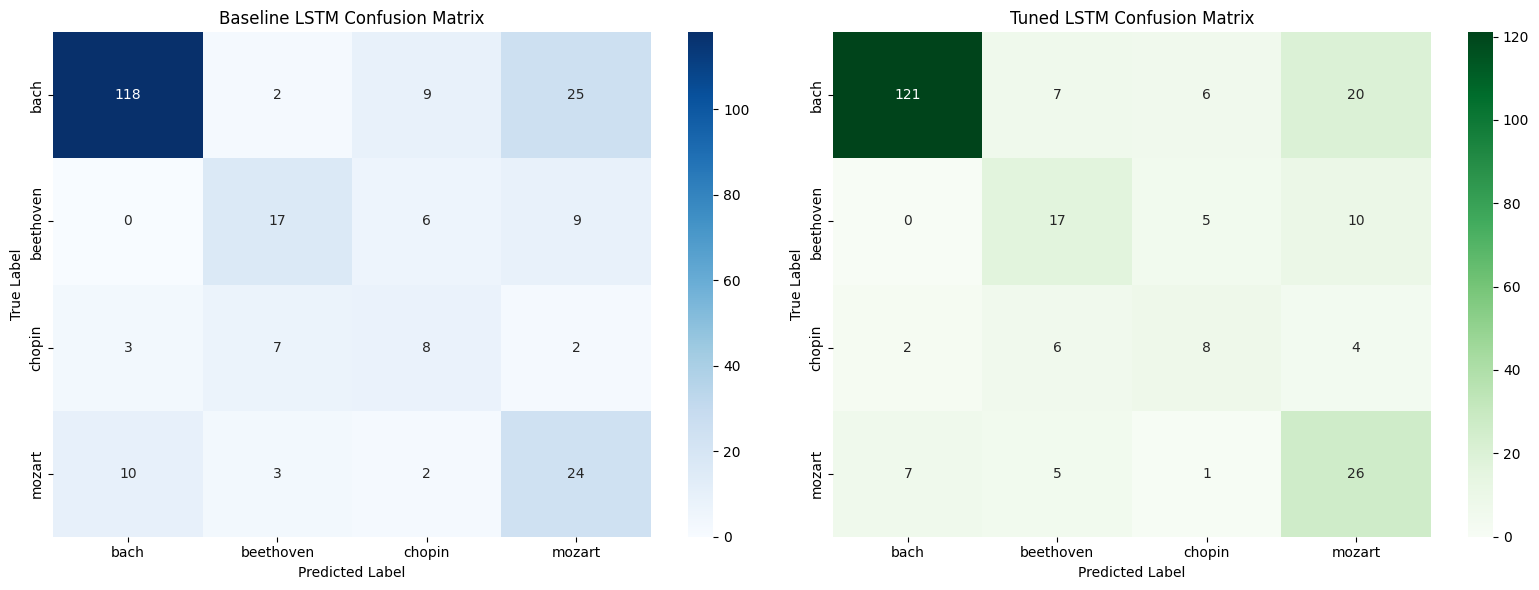

Saved confusion matrix plot to: /content/composer_classification_processed/lstm_confusion_matrices.png


In [33]:
baseline_cm = confusion_matrix(y_test, baseline_preds)
tuned_cm = confusion_matrix(y_test, tuned_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)
axes[0].set_title("Baseline LSTM Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)
axes[1].set_title("Tuned LSTM Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()

confusion_matrix_plot_path = PROCESSED_DIR / "lstm_confusion_matrices.png"
plt.savefig(confusion_matrix_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix plot to:", confusion_matrix_plot_path)

## 16.4 Save Evaluation Reports, Histories, Confusion Matrices, and Models


In [34]:
baseline_history_path = PROCESSED_DIR / "baseline_lstm_history.csv"
tuned_history_path = PROCESSED_DIR / "tuned_lstm_history.csv"

baseline_history_df.to_csv(baseline_history_path, index=False)
tuned_history_df.to_csv(tuned_history_path, index=False)

baseline_report_df = pd.DataFrame(baseline_report_dict).transpose()
tuned_report_df = pd.DataFrame(tuned_report_dict).transpose()

baseline_report_path = PROCESSED_DIR / "baseline_classification_report.csv"
tuned_report_path = PROCESSED_DIR / "tuned_classification_report.csv"

baseline_report_df.to_csv(baseline_report_path)
tuned_report_df.to_csv(tuned_report_path)

baseline_cm_df = pd.DataFrame(baseline_cm, index=class_names, columns=class_names)
tuned_cm_df = pd.DataFrame(tuned_cm, index=class_names, columns=class_names)

baseline_cm_path = PROCESSED_DIR / "baseline_confusion_matrix.csv"
tuned_cm_path = PROCESSED_DIR / "tuned_confusion_matrix.csv"

baseline_cm_df.to_csv(baseline_cm_path)
tuned_cm_df.to_csv(tuned_cm_path)

baseline_model_path = PROCESSED_DIR / "baseline_lstm_model.keras"
tuned_model_path = PROCESSED_DIR / "tuned_lstm_model.keras"

baseline_lstm.save(baseline_model_path)
tuned_lstm.save(tuned_model_path)

print("Saved:")
print("-", baseline_history_path)
print("-", tuned_history_path)
print("-", baseline_report_path)
print("-", tuned_report_path)
print("-", baseline_cm_path)
print("-", tuned_cm_path)
print("-", baseline_model_path)
print("-", tuned_model_path)
print("-", baseline_history_plot_path)
print("-", tuned_history_plot_path)
print("-", confusion_matrix_plot_path)

Saved:
- /content/composer_classification_processed/baseline_lstm_history.csv
- /content/composer_classification_processed/tuned_lstm_history.csv
- /content/composer_classification_processed/baseline_classification_report.csv
- /content/composer_classification_processed/tuned_classification_report.csv
- /content/composer_classification_processed/baseline_confusion_matrix.csv
- /content/composer_classification_processed/tuned_confusion_matrix.csv
- /content/composer_classification_processed/baseline_lstm_model.keras
- /content/composer_classification_processed/tuned_lstm_model.keras
- /content/composer_classification_processed/baseline_lstm_history.png
- /content/composer_classification_processed/tuned_lstm_history.png
- /content/composer_classification_processed/lstm_confusion_matrices.png


## 16.5 Create a Final Results Summary and Select the Best Model

In [35]:
results_summary = pd.DataFrame([
    {
        "model": "baseline_lstm",
        "test_loss": baseline_test_loss,
        "accuracy": baseline_accuracy,
        "precision_weighted": baseline_precision,
        "recall_weighted": baseline_recall,
        "f1_weighted": baseline_f1
    },
    {
        "model": "tuned_lstm",
        "test_loss": tuned_test_loss,
        "accuracy": tuned_accuracy,
        "precision_weighted": tuned_precision,
        "recall_weighted": tuned_recall,
        "f1_weighted": tuned_f1
    }
])

results_summary_path = PROCESSED_DIR / "lstm_results_summary.csv"
results_summary.to_csv(results_summary_path, index=False)

best_model_row = results_summary.sort_values(by="f1_weighted", ascending=False).iloc[0]
best_model_name = str(best_model_row["model"])

best_model_info = {
    "best_model": best_model_name,
    "selection_metric": "weighted_f1",
    "best_metric_value": float(best_model_row["f1_weighted"])
}

best_model_info_path = PROCESSED_DIR / "best_lstm_model_selection.json"
with open(best_model_info_path, "w") as f:
    json.dump(best_model_info, f, indent=2)

print("Results summary:")
print(results_summary)

print("\nBest model based on weighted F1-score:", best_model_name)
print("Saved results summary to:", results_summary_path)
print("Saved model selection metadata to:", best_model_info_path)

Results summary:
           model  test_loss  accuracy  precision_weighted  recall_weighted  \
0  baseline_lstm   0.854255  0.681633            0.732556         0.681633   
1     tuned_lstm   0.796924  0.702041            0.750128         0.702041   

   f1_weighted  
0     0.699506  
1     0.718159  

Best model based on weighted F1-score: tuned_lstm
Saved results summary to: /content/composer_classification_processed/lstm_results_summary.csv
Saved model selection metadata to: /content/composer_classification_processed/best_lstm_model_selection.json


## 16.6 Results Interpretation

The held-out test set was evaluated using accuracy, precision, a weighted F-1 score, and recall for both the baseline and the tuned LSTM model. With the baseline model, I was able to get an initial measurement of the progress of using a single-layer LSTM from sequential musical feature data to classify composers. The tuned model was made to test if overall performance could be improved based on having a deeper architecture. The most important values we looked at when comparing the two models were the weighted F-1 score, weighted recall, weighted precision, and the confusion matrices. The model that showed a more balanced class-level performance and a stronger weighted F-1 score is the best LSTM approach to choose. Additionally, the classification reports and confusion matrices should be used to evaluate the easiest to most difficult composers to distinguish from one another.

## 16.7 Limitations and Future Improvement

There are some limitations that I would like to bring to light, even though the model is able to give sequential structure in the musical dataset. One limitation that can greatly affect the model's performance, even with the class weights, is the class imbalance of the dataset. Another factor that may influence the effectiveness of the represented long-range musical structure is the padding strategy and the selected maximum sequence length. Lastly, the extracted feature representation (chord span, tempo, chord size, duration, pitch, time shift, and velocity) also heavily affects the model's overall performance. For future improvement, I would consider broader hyperparameter tuning. I could also consider different architectures or additional deep learning approaches, or refine my feature engineering strategies to make improvements across composer generalization.

## 16.8 Verify Final Output Files


In [36]:
expected_output_files = [
    "baseline_lstm_best.keras",
    "tuned_lstm_best.keras",
    "baseline_lstm_model.keras",
    "tuned_lstm_model.keras",
    "baseline_lstm_history.csv",
    "tuned_lstm_history.csv",
    "baseline_classification_report.csv",
    "tuned_classification_report.csv",
    "baseline_confusion_matrix.csv",
    "tuned_confusion_matrix.csv",
    "lstm_results_summary.csv",
    "lstm_hyperparameter_summary.csv",
    "best_lstm_model_selection.json",
    "baseline_lstm_history.png",
    "tuned_lstm_history.png",
    "lstm_confusion_matrices.png"
]

print("Final output file check:\n")
for file_name in expected_output_files:
    file_path = PROCESSED_DIR / file_name
    print(f"{file_name}: {'FOUND' if file_path.exists() else 'MISSING'}")

Final output file check:

baseline_lstm_best.keras: FOUND
tuned_lstm_best.keras: FOUND
baseline_lstm_model.keras: FOUND
tuned_lstm_model.keras: FOUND
baseline_lstm_history.csv: FOUND
tuned_lstm_history.csv: FOUND
baseline_classification_report.csv: FOUND
tuned_classification_report.csv: FOUND
baseline_confusion_matrix.csv: FOUND
tuned_confusion_matrix.csv: FOUND
lstm_results_summary.csv: FOUND
lstm_hyperparameter_summary.csv: FOUND
best_lstm_model_selection.json: FOUND
baseline_lstm_history.png: FOUND
tuned_lstm_history.png: FOUND
lstm_confusion_matrices.png: FOUND


## 16.9 Record Package Versions

In [37]:
print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("TensorFlow version:", tf.__version__)
print("scikit-learn version:", sklearn.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:", sns.__version__)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy version: 2.0.2
Pandas version: 2.2.2
TensorFlow version: 2.20.0
scikit-learn version: 1.6.1
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
